# 5.0 — v2 Data-Crafting Acceptance Report (Phase 8)

Thin presentation layer over `scripts/build/build_v2_report.py::build_report()` — the **same pure
function the gate tests assert on** (`tests/data_crafting/test_acceptance_v2.py`). The numbers and
the green/red gates live in that function; this notebook only renders them. Diffs the Phase-0
baseline (`baseline_distribution.json`) against the v2 craft (`dot_archive_v2.jsonl` +
`dot_splits_v2.npz`). All CPU-only, deterministic (`SEED=0`).

**Read the framing, not just the bars.** `counterexample_eval` (8 named) is *all-hard, no
ground-truth d-o-t → no MAE*; it is a **length-stratified separation/ranking** metric, never one
8-row number. The **headline** band loss-mass is the **TRAIN** cut ("what actually trains"); the
whole-archive `.256/.358/.128/.257` is the Phase-5 reproduction. `bound_B` (48/150) is a heuristic
floor, never a lower bound. See §8 for the full caveat list.


## 1. Setup — find the repo root, build the report

In [1]:
%matplotlib inline
import os, sys, json
# robust repo-root discovery: walk up to the dir holding scripts/lib/dot_config.py
_d = os.getcwd()
while not os.path.exists(os.path.join(_d, "scripts", "lib", "dot_config.py")) and _d != os.path.dirname(_d):
    _d = os.path.dirname(_d)
os.chdir(_d); sys.path.insert(0, _d)
import numpy as np
import matplotlib.pyplot as plt
from scripts.build import build_v2_report as rpt
from scripts.lib import dot_config as cfg

rep = rpt.build_report(write=True)          # writes data/derived/dot/v2_report.json + runs all gates
A = rep["assertions"]
print(f"v2 acceptance: {sum(A.values())}/{len(A)} assertions green | rows={rep['n_rows']} "
      f"labelled={rep['n_labelled']} censored={rep['n_censored_generic']} named={rep['n_named']}")

wrote data/derived/dot/v2_report.json
v2 acceptance: 15/15 assertions green | rows=38384 labelled=33422 censored=4954 named=8


## 2. Headline — band loss-mass: §2 target vs archive vs TRAIN cut

The TRAIN cut is the operative number. `hard_solved` is **doubly depleted** (top-5% frozen into `hard_test` + the ×0.5 far-tail discount), so it sits below the .128 archive value *by design*.

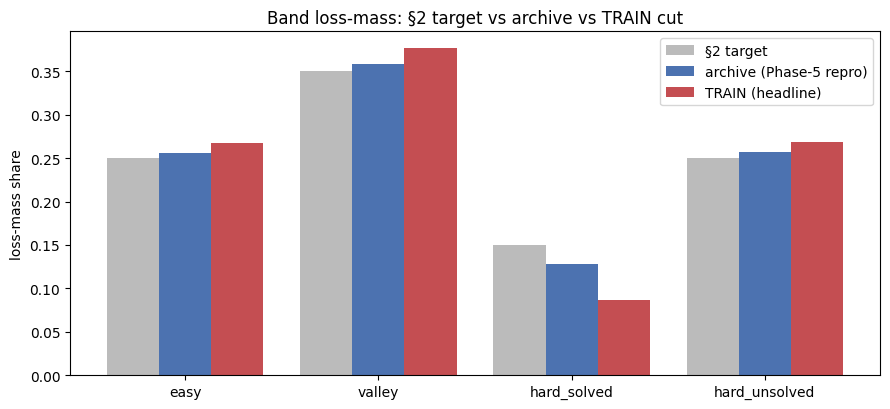

archive: {'easy': 0.256, 'valley': 0.358, 'hard_solved': 0.129, 'hard_unsolved': 0.257}
train  : {'easy': 0.267, 'valley': 0.377, 'hard_solved': 0.087, 'hard_unsolved': 0.269}


In [2]:
bands = list(cfg.TARGET_SHARES)
tgt  = [cfg.TARGET_SHARES[b] for b in bands]
arch = [rep["bands"]["band_mass_archive"][b] for b in bands]
trn  = [rep["bands"]["band_mass_train_HEADLINE"][b] for b in bands]
x = np.arange(len(bands)); w = 0.27
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(x - w, tgt, w, label="§2 target", color="#bbbbbb")
ax.bar(x,     arch, w, label="archive (Phase-5 repro)", color="#4c72b0")
ax.bar(x + w, trn, w, label="TRAIN (headline)", color="#c44e52")
ax.set_xticks(x); ax.set_xticklabels(bands); ax.set_ylabel("loss-mass share")
ax.set_title("Band loss-mass: §2 target vs archive vs TRAIN cut")
ax.legend(); fig.tight_layout(); plt.show()
print("archive:", {b: round(arch[i],3) for i,b in enumerate(bands)})
print("train  :", {b: round(trn[i],3)  for i,b in enumerate(bands)})

## 3. d-o-t distribution — raw vs weighted (labelled)

Reweighting pulls mass off the easy hump (0–10) toward the valley/hard-solved tail without resampling. **Weight mass ≠ gradient mass** — hinge (censored) and regression (labelled) are different scales (§8).

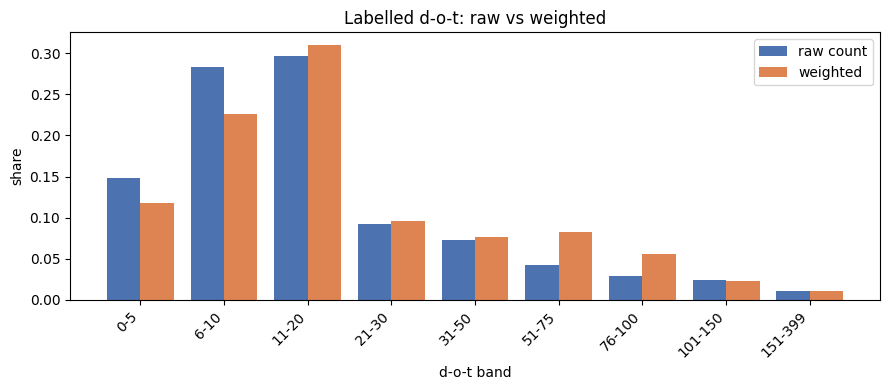

In [3]:
dh = rep["dot_histogram_labelled"]; edges = dh["edges"]
labels = [f"{edges[i]}-{edges[i+1]-1}" for i in range(len(edges)-1)]
xx = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(xx-0.2, np.array(dh["raw"])/sum(dh["raw"]), 0.4, label="raw count", color="#4c72b0")
ax.bar(xx+0.2, np.array(dh["weighted"])/sum(dh["weighted"]), 0.4, label="weighted", color="#dd8452")
ax.set_xticks(xx); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("d-o-t band"); ax.set_ylabel("share"); ax.legend()
ax.set_title("Labelled d-o-t: raw vs weighted")
fig.tight_layout(); plt.show()

## 4. Length × hardness — hard mass spread across lengths

Baseline hard (censored) mass is pinned at len 15–17. The named anchors add hard mass at len **19/21/23** (AK(6/7/8)) where the raw data had none — a *small* extension (16 rows total), not a claim that decorrelation rebalanced length (§8).

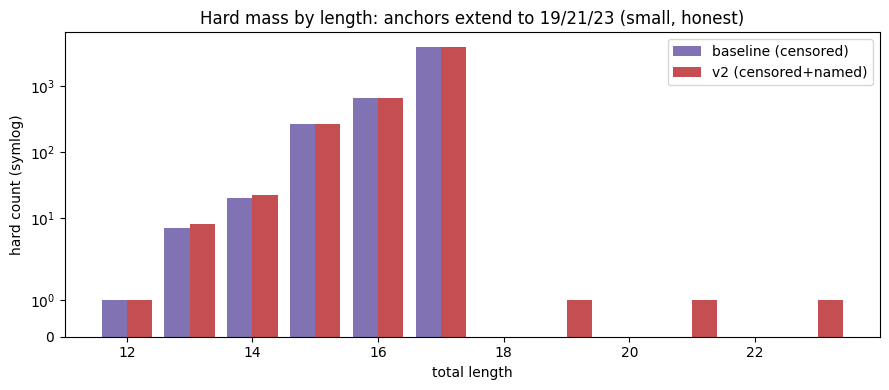

v2 hard-by-length: {'12': 1, '13': 8, '14': 22, '15': 267, '16': 659, '17': 4002, '19': 1, '21': 1, '23': 1}


In [4]:
spread = rep["hard_length_spread"]
base = spread["baseline_censored"]; v2 = spread["v2_censored_plus_named"]
lens = sorted({int(k) for k in base} | {int(k) for k in v2})
bvals = [base.get(str(L), 0) for L in lens]; vvals = [v2.get(str(L), 0) for L in lens]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([L-0.2 for L in lens], bvals, 0.4, label="baseline (censored)", color="#8172b3")
ax.bar([L+0.2 for L in lens], vvals, 0.4, label="v2 (censored+named)", color="#c44e52")
ax.set_yscale("symlog"); ax.set_xlabel("total length"); ax.set_ylabel("hard count (symlog)")
ax.set_title("Hard mass by length: anchors extend to 19/21/23 (small, honest)")
ax.legend(); fig.tight_layout(); plt.show()
print("v2 hard-by-length:", v2)

## 5. Provenance — source mix per band + per-fold counts

In [5]:
fc = rep["fold_counts"]
print("per-fold counts:", {f: fc[f]["n"] for f in fc}, " sum =", sum(fc[f]["n"] for f in fc))
for b in bands:
    print(f"  source mix [{b:13s}]:", rep["source_mix_by_band"][b])

per-fold counts: {'train': 29365, 'val': 3670, 'test': 3670, 'hard_test': 1671, 'counterexample_eval': 8}  sum = 38384
  source mix [easy         ]: {'beam+greedy': 985, 'beam': 8154, 'greedy': 5290}
  source mix [valley       ]: {'beam': 14311, 'beam+greedy': 202, 'greedy': 911}
  source mix [hard_solved  ]: {'beam': 2635, 'beam+greedy': 48, 'greedy': 886}
  source mix [hard_unsolved]: {'censored (no source recorded)': 4954, 'anchor': 8}


## 6. Diversity drop — anti-diverse, single-path-skewed

Phase 3 deleted 4,074 easy rows; **68.5% were touched by a single path** — the stride is a weak decorrelator that skews to rare classes. The *real* easy-mass control is Phase-5 reweighting + the by-class split, not this drop (§8). Shown for honesty, not as a decorrelation win.

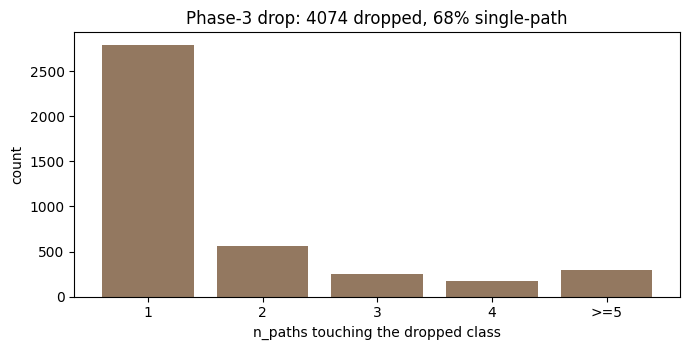

In [6]:
d = rep["diversity_drop"]; h = {int(k): v for k, v in d["drop_n_paths_hist"].items()}
ks = sorted(h)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar([str(k) if k < 5 else ">=5" for k in ks], [h[k] for k in ks], color="#937860")
ax.set_xlabel("n_paths touching the dropped class"); ax.set_ylabel("count")
ax.set_title(f"Phase-3 drop: {d['n_dropped']} dropped, {d['single_path_frac']*100:.0f}% single-path")
fig.tight_layout(); plt.show()

## 7. Eval reframed — per-anchor confound map (length vs r1-leakage)

Never publish one 8-row "hardness" number, and **never MAE** (no ground truth on the anchors). The eval is **separation vs a baseline**. A length-exploiting regression head predicts ≈ `solved_median_dot(L)`, which **rises monotonically** with length — so against v1's single len-13-14 baseline the **longer** anchors gain the **largest spurious separation** (AK(8)@23: +17): AK(6/7/8) are the *most* length-gameable, **not** the least. The **len≤14** anchors (AK(3), Length-14) are length-matched (≈0 spurious sep); AK(3)'s real confound is its **r1-cousins** (train rows sharing r1 `YXYxyx`). **Fix (model plan): per-length-matched baselines** `P(AK(n)@L) ≫ P(solved@L)` — removes the length confound from all 8 anchors.

In [7]:
e = rep["eval_reframed"]
print(f"{'label':>12s} {'len':>3s} {'smd':>4s} {'len_sep':>7s} {'r1_cous':>7s}  confound | stratum")
for it in e["per_instance"]:
    print(f"  {it['label']:>10s} {it['total_len']:>3d} {str(it['in_dist_solved_median_dot']):>4s} "
          f"{str(it['length_baseline_separation']):>7s} {it['r1_cousins_in_train']:>7d}  "
          f"{it['dominant_confound_under_v1']} | {it['v1_stratum']}")
av = e["ak3_vs_lookalike"]
print(f"\nAK(3) {av['ak3_key']} -> {av['ak3_fold']};  look-alike {av['lookalike_key']} -> "
      f"{av['lookalike_fold']}  (n=1 probe)")
cp = e["contrast_populations"]
print(f"\nper-length solved baselines (the constructive fix): {cp['per_length_solved_baseline']}")
print("NOTE:", cp["note"])

       label len  smd len_sep r1_cous  confound | stratum
       AK(3)  13  6.0     0.0     116  r1_cousin_leakage | length_matched_to_v1_baseline(len<=14)
  Length 14 #1  14  7.0     1.0      32  length_matched(residual: structure) | length_matched_to_v1_baseline(len<=14)
  Length 14 #2  14  7.0     1.0      32  length_matched(residual: structure) | length_matched_to_v1_baseline(len<=14)
       AK(4)  15  8.0     2.0     116  length_baseline_separation | needs_per_length_baseline(len>=15)
       AK(5)  17  9.0     3.0     116  length_baseline_separation | needs_per_length_baseline(len>=15)
       AK(6)  19 15.0     9.0     116  length_baseline_separation | needs_per_length_baseline(len>=15)
       AK(7)  21 18.0    12.0     116  length_baseline_separation | needs_per_length_baseline(len>=15)
       AK(8)  23 23.0    17.0     116  length_baseline_separation | needs_per_length_baseline(len>=15)

AK(3) YXYxyx|YYYYxxx -> ['counterexample_eval'];  look-alike YXyxYx|YYYYxxx -> ['train']  (n

## 8. Acceptance assertions (all green) + caveats

In [8]:
print("ASSERTIONS")
for k, v in A.items():
    print(f"  [{'OK' if v else 'XX'}] {k}")
assert all(A.values()), "RED assertion(s) present -- build_report would have raised"
print("\nCAVEATS carried into the model plan:")
for c in rep["caveats"]:
    print("  -", c)
print("\nv2_report.json written to data/derived/dot/v2_report.json")
print("ALL GREEN" if all(A.values()) else "RED")

ASSERTIONS
  [OK] AK3_in_counterexample_eval_only
  [OK] AK3_tier_named
  [OK] AK3_not_in_train
  [OK] 8_cousins_present_and_in_train
  [OK] lookalike_in_train
  [OK] lookalike_absent_from_trapset
  [OK] no_key_in_two_folds
  [OK] mean_weight_~1
  [OK] archive_band_mass_within_tol
  [OK] eval_v1_length_matched_n3
  [OK] eval_needs_per_length_n5
  [OK] eval_length_separation_monotone
  [OK] eval_AK8_most_length_gameable
  [OK] rederived_band_mass_matches_committed
  [OK] env_to_canonkey_roundtrip_AK3

CAVEATS carried into the model plan:
  - counterexample_eval is all-hard, no ground-truth d-o-t -> NO MAE; report as separation/ranking.
  - DOMINANT confound for AK(3): r1-cousin leakage -- AK(3) is length-matched to the baseline so length buys ~0 separation; it is passable by matching r1='YXYxyx', seen labelled-hard in its train cousins -> NOT clean de-novo recognition (per-anchor, not a global ordering).
  - Length confound (mechanism): solved_median_dot(L) -- what a length regression h